# Fake News Project

## Part 1 – Data Processing

This notebook performs the following steps:

1. Load and structure the dataset
2. Clean and preprocess the text data
3. Apply the preprocessing pipeline to the 995K FakeNewsCorpus subset
4. Create train / validation / test splits (80 / 10 / 10)

### Imports and setup

In [43]:
import re
import pandas as pd
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True)
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split

# Download NLTK resources if needed
nltk.download("punkt")
nltk.download("stopwords")

STOP_WORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()
RANDOM_STATE = 22

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ellenjordan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ellenjordan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Helper functions

In [44]:
def clean_content_df(df, text_col="content"):
    """Keep rows with non-missing, non-empty text and ensure text is string."""
    df2 = df.dropna(subset=[text_col]).copy()
    df2[text_col] = df2[text_col].astype(str)
    df2 = df2[df2[text_col].str.strip().ne("")].copy()
    return df2

def tokenize_series(text_series):
    """Tokenize each document into lowercase tokens and return one flat list."""
    all_tokens = []
    for text in text_series:
        all_tokens.extend(word_tokenize(text.lower()))
    return all_tokens

def remove_stopwords(tokens):
    return [token for token in tokens if token not in STOP_WORDS]

def stem_tokens(tokens):
    return [STEMMER.stem(token) for token in tokens]

def vocab_size(tokens):
    return len(set(tokens))

def reduction_rate(before, after):
    return (before - after) / before if before else 0

def count_urls(text):
    return len(re.findall(r"https?://\S+|www\.\S+", str(text)))

def count_dates(text):
    patterns = [
        r"\b\d{4}-\d{2}-\d{2}\b",              # 2024-02-17
        r"\b\d{1,2}/\d{1,2}/\d{2,4}\b",        # 17/02/2024
        r"\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\s+\d{1,2},?\s+\d{4}\b"
    ]
    return sum(len(re.findall(p, str(text), flags=re.IGNORECASE)) for p in patterns)

def count_numbers(text):
    return len(re.findall(r"\b\d+(?:[\.,]\d+)?\b", str(text)))

def top_n_words(tokens, n=100):
    return pd.Series(tokens).value_counts().head(n)

## Task 1 – Retrieve, structure, clean, and preprocess the sample dataset

In [45]:
sample_url = "https://raw.githubusercontent.com/several27/FakeNewsCorpus/master/news_sample.csv"
df_sample = pd.read_csv(sample_url)

print("Shape (rows, cols):", df_sample.shape)
print("Columns:", df_sample.columns.tolist())

df_sample.head(3)

,Unnamed: 0,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary
0,0,141,awm.com,unreliable,http://awm.com/church-congregation-brings-gift...,Sometimes the power of Christmas will make you...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Church Congregation Brings Gift to Waitresses ...,Ruth Harris,NaN,[''],NaN,NaN,NaN
1,1,256,beforeitsnews.com,fake,http://beforeitsnews.com/awakening-start-here/...,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,Zurich Times,NaN,[''],NaN,NaN,NaN
2,2,700,cnnnext.com,unreliable,http://www.cnnnext.com/video/18526/never-hike-...,Never Hike Alone: A Friday the 13th Fan Film U...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Never Hike Alone - A Friday the 13th Fan Film ...,NaN,NaN,[''],Never Hike Alone: A Friday the 13th Fan Film ...,NaN,NaN


In [46]:
text_col = "content"

print("Missing content:", df_sample[text_col].isna().sum())

df_sample_clean = clean_content_df(df_sample, text_col=text_col)

print("Before cleaning:", df_sample.shape)
print("After cleaning: ", df_sample_clean.shape)

df_sample_clean[[text_col, "type", "domain"]].head(3)

,content,type,domain
0,Sometimes the power of Christmas will make you...,unreliable,awm.com
1,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,fake,beforeitsnews.com
2,Never Hike Alone: A Friday the 13th Fan Film U...,unreliable,cnnnext.com


In [47]:
# Tokenization on sample dataset
tokens_sample = tokenize_series(df_sample_clean["content"])
vocab_sample_before = vocab_size(tokens_sample)

print("Vocabulary size before stopword removal:", vocab_sample_before)

Vocabulary size before stopword removal: 17913


In [48]:
# Stopword removal on sample dataset
tokens_sample_no_stop = remove_stopwords(tokens_sample)
vocab_sample_after_stop = vocab_size(tokens_sample_no_stop)
reduction_sample_stop = reduction_rate(vocab_sample_before, vocab_sample_after_stop)

print("Vocabulary size after stopword removal:", vocab_sample_after_stop)
print("Reduction rate after stopword removal:", reduction_sample_stop)

Vocabulary size after stopword removal: 17767
Reduction rate after stopword removal: 0.008150505219672864


In [49]:
# Stemming on sample dataset
tokens_sample_stem = stem_tokens(tokens_sample_no_stop)
vocab_sample_after_stem = vocab_size(tokens_sample_stem)
reduction_sample_stem = reduction_rate(vocab_sample_before, vocab_sample_after_stem)

print("Vocabulary size after stemming:", vocab_sample_after_stem)
print("Reduction rate after stemming:", reduction_sample_stem)

Vocabulary size after stemming: 12603
Reduction rate after stemming: 0.2964327583319377


#PART 2

The text data is processed using tokenization, stopword removal, and stemming.

In [50]:
import pandas as pd
import re
import nltk
from pandarallel import pandarallel
from cleantext import clean
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Initialize parallel processing
pandarallel.initialize(progress_bar=True)

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

# Load data
file_path = "995k_rows.csv"
df = pd.read_csv(file_path)

df = df.dropna(subset=["content"])
df["content"] = df["content"].astype(str)
df = df[df["content"].str.strip().ne("")].copy()

# Setup stopwords og stemmer
stop_words = set(stopwords.words('english'))
stop_words.update(['number', 'numb'])
stemmer = SnowballStemmer("english")


# CLEAN funktionen

def clean_text_library(text):
    if pd.isnull(text):
        return ""
    text = re.sub(r'http\S+|www\S+', '', text)
    text = clean(
        text,
        lower=True,
        no_urls=True,
        no_emails=True,
        no_numbers=True,
        no_line_breaks=True
    )
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df["content"].parallel_apply(clean_text_library)


#Remove stopwords

def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in stop_words])

df["no_stopwords"] = df["clean_text"].parallel_apply(remove_stopwords)

#stemming
def apply_stemming(text):
    return " ".join([stemmer.stem(w) for w in text.split()])

df["stemmed"] = df["no_stopwords"].parallel_apply(apply_stemming)


def build_vocab(series, batch_size=50000):
    vocab = set()
    for i in range(0, len(series), batch_size):
        batch = series.iloc[i:i+batch_size]
        for text in batch:
            vocab.update(text.split())
    return vocab

vocab_original = build_vocab(df["clean_text"])
vocab_no_stopwords = build_vocab(df["no_stopwords"])
vocab_stemmed = build_vocab(df["stemmed"])

# Compute sizes + reductions
size_original = len(vocab_original)
size_no_stopwords = len(vocab_no_stopwords)
size_stemmed = len(vocab_stemmed)

reduction_stopwords = ((size_original - size_no_stopwords) / size_original) * 100
reduction_stemming = ((size_no_stopwords - size_stemmed) / size_no_stopwords) * 100

print(f"Original Vocabulary Size: {size_original}")
print(f"Vocabulary Size after Stopwords: {size_no_stopwords}")
print(f"Reduction Rate after Stopwords: {reduction_stopwords:.2f}%")
print(f"Vocabulary Size after Stemming: {size_stemmed}")
print(f"Reduction Rate after Stemming: {reduction_stemming:.2f}%")


#df[["clean_text"]].to_csv("clean_text_lib.csv", index=False)
#df[["no_stopwords"]].to_csv("clean_text_no_stopwords.csv", index=False)
#df[["stemmed"]].to_csv("clean_text_stemmed.csv", index=False)


Original Vocabulary Size: 1897419
Vocabulary Size after Stopwords: 1897266
Reduction Rate after Stopwords: 0.01%
Vocabulary Size after Stemming: 1630795
Reduction Rate after Stemming: 14.04%


In [51]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
if "id" in df.columns:
    df["id"] = df["id"].astype(str)

df.reset_index(drop=True).to_feather("df_processed.feather")
print("DataFrame saved to df_processed.feather")


DataFrame saved to df_processed.feather


## Task 2 – Apply the preprocessing pipeline to the 995K dataset

## Task 3 – Explore the processed 995K dataset
Below are analyses that can support at least three non-trivial observations in the report.

In [52]:
df_995k_clean = pd.read_feather("df_processed.feather")

In [53]:
df_995k_clean["type"] = df_995k_clean["type"].astype(str)
df_995k_clean["domain"] = df_995k_clean["domain"].astype(str)

print("Number of rows after cleaning:", len(df_995k_clean))
print("Unique type values:", df_995k_clean["type"].nunique())
print("Unique domains:", df_995k_clean["domain"].nunique())


Number of rows after cleaning: 994988
Unique type values: 14
Unique domains: 683


In [54]:
# Observation candidate 1: suspicious / corrupted label values in 'type'
type_counts = df_995k_clean["type"].value_counts()
print(type_counts.head(20))

timestamp_like_types = df_995k_clean[df_995k_clean["type"].str.match(r"^\d{4}-\d{2}-\d{2}", na=False)]
print("\nRows with timestamp-like values in 'type':", len(timestamp_like_types))
timestamp_like_types.head(3)

,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary,source,clean_text,no_stopwords,stemmed
908181,Financials 7:50am EST BRIEF-Al Tawfeek Co fo...,2016-11-13T15:38:41.407+02:00,2018-02-10 13:43:39.521661,2018-02-10 13:43:39.521686,BRIEF-Al Tawfeek Co for Financial Leasing Q3 p...,None,None,None,None,None,NaN,webhose,None,None,NaN,None,briefal tawfeek co for financial leasing qnumb...,briefal tawfeek co financial leasing qnumber p...,briefal tawfeek co financi leas qnumber profit...


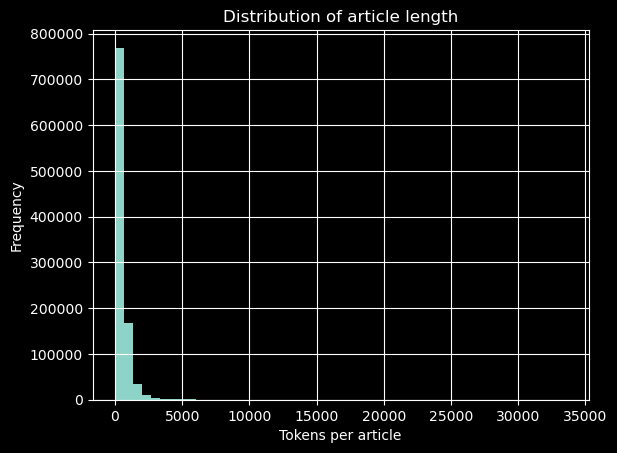

In [55]:
# Observation candidate 2: article length variation
df_995k_clean["token_count"] = df_995k_clean["content"].apply(
    lambda x: len(re.findall(r'\b\w+\b', str(x)))
)

print(df_995k_clean["token_count"].describe())

df_995k_clean["token_count"].hist(bins=50)
plt.xlabel("Tokens per article")
plt.ylabel("Frequency")
plt.title("Distribution of article length")
plt.show()

In [56]:
# Observation candidate 3: structural signals in text
df_995k_clean["url_count"] = df_995k_clean["content"].parallel_apply(count_urls)
df_995k_clean["date_count"] = df_995k_clean["content"].parallel_apply(count_dates)
df_995k_clean["number_count"] = df_995k_clean["content"].parallel_apply(count_numbers)

print(df_995k_clean[["url_count", "date_count", "number_count"]].describe())

           url_count     date_count   number_count
count  994988.000000  994988.000000  994988.000000
mean        0.270777       0.369054       8.875503
std         2.507107       2.656540      29.020474
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       1.000000
50%         0.000000       0.000000       3.000000
75%         0.000000       0.000000       9.000000
max      1984.000000    1015.000000    4653.000000


In [57]:
# Top frequent words before and after preprocessing
top100_before = top_n_words(df_995k_clean["clean_text"], n=100)
top100_after  = top_n_words(df_995k_clean["stemmed"],    n=100)

print("Top 20 words before stopword removal / stemming:")
print(top100_before.head(20).to_string())

print("\nTop 20 words after stopword removal + stemming:")
print(top100_after.head(20).to_string())

Top 20 words before stopword removal / stemming:
clean_text
plus one article on google plus thanks to ali alfoneh for his assistance in compiling politics nuclear issue supreme leader tells islamic student associations at foreign universities conspiracies and machinations of the enemy including the scientific apartheid which they try to subject our nation to only strengthens the unity of our people head of irans nuclear energy agency conditions not right for implementation of the additional protocol more reactors coming online military admiral habiballah sayyari chief of the islamic republic of iran navy closure of the hormuz strait is not under consideration during upcoming war games added that iranianmade submarines are soon to leave docks in southern iran seyyedyahya rahim safavi former irgc head and current advisor to supreme leader risk of an attack against iran is minimal irans defense doctrine does not entail nuclear weapons society and culture iranian psychologist davar sheikha

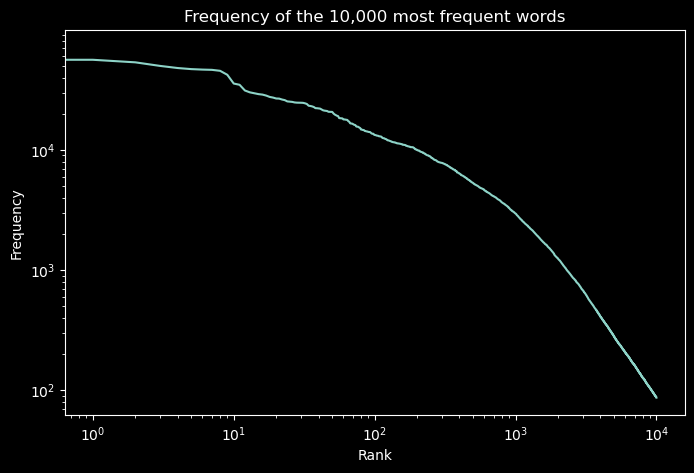

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

df_sample = df_995k_clean["stemmed"].dropna().sample(50000, random_state=22)

tokens = df_sample.str.split().explode() #chatgpt foreslog denne måde at bygge tokens

top10000 = tokens.value_counts().head(10000)

plt.figure(figsize=(8, 5))
plt.plot(top10000.values)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Frequency of the 10,000 most frequent words")
plt.yscale("log")
plt.xscale("log")
plt.show()

## Task 4 – Create train / validation / test splits
We create 80% / 10% / 10% splits with stratification on the label column.

In [59]:
# Remove rows without labels and optionally remove clearly corrupted labels
df_split = df_995k_clean.dropna(subset=["content", "type"]).copy()
df_split = df_split[~df_split["type"].astype(str).str.match(r"^\d{4}-\d{2}-\d{2}", na=False)].copy()

X = df_split["content"]
y = df_split["type"]

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: split temp into 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 795989
Validation size: 99499
Test size: 99499


In [60]:
print("Train distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(3))

print("\nValidation distribution (%):")
print((y_val.value_counts(normalize=True) * 100).round(3))

print("\nTest distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(3))

Train distribution (%):
type
reliable      21.966
political     19.550
bias          13.390
fake          10.541
conspiracy     9.780
rumor          5.673
None           4.802
unknown        4.375
unreliable     3.551
clickbait      2.755
junksci        1.411
satire         1.323
hate           0.882
Name: proportion, dtype: float64

Validation distribution (%):
type
reliable      21.967
political     19.550
bias          13.390
fake          10.542
conspiracy     9.781
rumor          5.672
None           4.801
unknown        4.375
unreliable     3.551
clickbait      2.755
junksci        1.411
satire         1.323
hate           0.882
Name: proportion, dtype: float64

Test distribution (%):
type
reliable      21.966
political     19.550
bias          13.390
fake          10.541
conspiracy     9.780
rumor          5.673
None           4.802
unknown        4.376
unreliable     3.551
clickbait      2.755
junksci        1.411
satire         1.323
hate           0.882
Name: proportion, dtyp

In [61]:
train_df = pd.DataFrame({"content": X_train, "type": y_train}).reset_index(drop=True)
val_df = pd.DataFrame({"content": X_val, "type": y_val}).reset_index(drop=True)
test_df = pd.DataFrame({"content": X_test, "type": y_test}).reset_index(drop=True)

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Saved: train.csv, val.csv, test.csv")

Saved: train.csv, val.csv, test.csv


In [62]:
#Part 2
#PART 2
#binary logistic regression (fake or not fake) kun to mulige udfald
#oprette et binært datasæt med fake og reliable, mange variable der forsvinder og ikke tagets ned.
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report


# 1. Load data fra Part 1
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

# 2. Label-mapping – samme gruppering i hele projektet
real_labels = ["reliable", "political"]
fake_labels = ["fake", "conspiracy", "rumor", "unreliable",
               "clickbait", "satire", "junksci", "hate", "bias"]
label_map = {l: 0 for l in real_labels}
label_map.update({l: 1 for l in fake_labels})

def prepare(df):
    df2 = df[df["type"].isin(label_map.keys())].copy()
    df2["label"] = df2["type"].map(label_map)
    df2["content"] = df2["content"].fillna("").str.lower() #for at fange både fake og Fake + fjernelse af NaN
    return df2

train = prepare(train_df)
test  = prepare(test_df)

X_train = train["content"]
y_train = train["label"]

X_test = test["content"]
y_test = test["label"]

#laver dataen om til vektore
vectoriser = CountVectorizer(max_features=10000) 
X_train_vec = vectoriser.fit_transform(X_train)
X_test_vec = vectoriser.transform(X_test)


model = LogisticRegression(max_iter=1000, random_state=22)
model.fit(X_train_vec, y_train)


y_pred = model.predict(X_test_vec)


F1 = f1_score(y_test, y_pred)
print("F1-score:", F1)
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/Users/ellenjordan/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


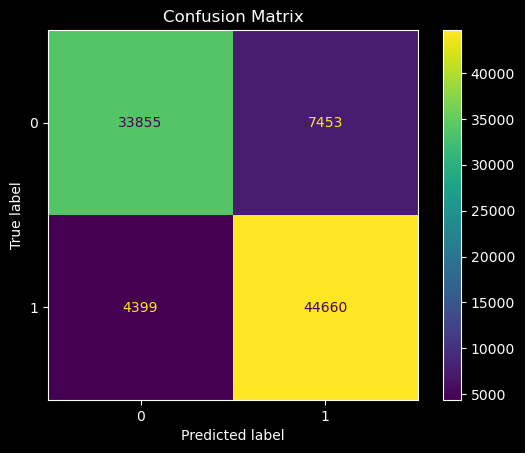

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [64]:
if "drop_labels" not in globals():
    drop_labels = ["unknown", "2018-02-10 13:43:39.521661"]

if "label_map" not in globals():
    real_labels = ["reliable", "political"]
    fake_labels = ["fake", "conspiracy", "rumor", "unreliable",
                   "clickbait", "satire", "junksci", "hate", "bias"]
    label_map = {l: 0 for l in real_labels}
    label_map.update({l: 1 for l in fake_labels})

def prepare_binary_dataset(df, text_col="content", label_col="type"):
    df2 = df.copy()
    df2[label_col] = df2[label_col].astype(str).str.strip()

    # Drop rows with missing text/labels
    df2 = df2.dropna(subset=[text_col, label_col]).copy()
    df2[text_col] = df2[text_col].astype(str)

    # Remove explicitly dropped labels
    df2 = df2[~df2[label_col].isin(drop_labels)].copy()

    # Keep only labels included in the binary mapping
    df2 = df2[df2[label_col].isin(label_map.keys())].copy()

    # Map to binary target
    df2["label"] = df2[label_col].map(label_map).astype(int)
    return df2

train_bin = prepare_binary_dataset(train_df)
val_bin = prepare_binary_dataset(val_df)
test_bin = prepare_binary_dataset(test_df)

print("Binary train:", train_bin.shape)
print("Binary val:", val_bin.shape)
print("Binary test:", test_bin.shape)


Binary train: (722942, 3)
Binary val: (90369, 3)
Binary test: (90367, 3)


In [65]:
print("Binary train distribution:")
print(train_bin["label"].value_counts(normalize=True).round(4))

Binary train distribution:
label
1    0.5429
0    0.4571
Name: proportion, dtype: float64


In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
X_train_text = train_bin["content"]
X_test_text = test_bin["content"]
X_val_text = val_bin["content"]
Y_train_text = train_bin["label"]
Y_test_text = test_bin["label"]
Y_val_text = val_bin["label"]

vectoriser = TfidfVectorizer(max_features=10000, stop_words="english", sublinear_tf=True)
X_train_vec = vectoriser.fit_transform(X_train_text)
X_test_vec = vectoriser.transform(X_test_text)
X_val_vec = vectoriser.transform(X_val_text)
model = LinearSVC(max_iter=1000, random_state=22)
model.fit(X_train_vec, Y_train_text)
y_pred = model.predict(X_test_vec)
F1 = f1_score(Y_test_text, y_pred)
print("F1-score:", F1)
print(classification_report(Y_test_text, y_pred))

F1-score: 0.8901929941315264
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     41308
           1       0.88      0.90      0.89     49059

    accuracy                           0.88     90367
   macro avg       0.88      0.88      0.88     90367
weighted avg       0.88      0.88      0.88     90367



In [67]:
df = pd.read_feather(
    "df_processed.feather",
    columns=["stemmed", "type"]
)

In [68]:
liar_df = pd.read_csv("test.tsv", sep="	", header=None)


In [69]:
print(liar_df.columns)
print(liar_df.iloc[:,1].unique())
print(liar_df.head(3))

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], dtype='int64')
['true' 'false' 'half-true' 'pants-fire' 'barely-true' 'mostly-true']
           0      1                                                  2   \
0  11972.json   true  Building a wall on the U.S.-Mexico border will...   
1  11685.json  false  Wisconsin is on pace to double the number of l...   
2  11096.json  false  Says John McCain has done nothing to help the ...   

                                3                  4                     5   \
0                      immigration         rick-perry              Governor   
1                             jobs  katrina-shankland  State representative   
2  military,veterans,voting-record       donald-trump       President-Elect   

          6           7   8    9   10  11  12                            13  
0      Texas  republican  30   30  42  23  18               Radio interview  
1  Wisconsin    democrat   2    1   0   0   0             a news conference  
2   New Y

In [70]:
#PART 3

In [71]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report
import joblib

In [72]:
def read_data_chunked(filepath, chunksize=100000):
    chunks = []
    reader = pd.read_csv(
        filepath,
        chunksize=chunksize,
        low_memory=False,
        usecols=['content', 'type']
    )
    total_rows = 0
    for i, chunk in enumerate(reader, 1):
        total_rows += len(chunk)
        chunks.append(chunk)
        print('Appended', total_rows, 'articles')
    return pd.concat(chunks, ignore_index=True)


In [73]:
def prepare_binary(df):
    real_labels = ["reliable", "political"]
    fake_labels = ["fake", "conspiracy", "rumor", "unreliable",
                   "clickbait", "satire", "junksci", "hate", "bias"]
    label_map = {l: 0 for l in real_labels}
    label_map.update({l: 1 for l in fake_labels})

    # Sørg for at type/content findes og er i brugbar form
    df = df.dropna(subset=["type", "content"])
    df["type"] = df["type"].astype(str).str.strip()
    df["content"] = df["content"].astype(str)

    # Behold kun labels, der findes i label_map
    df = df[df["type"].isin(label_map.keys())].copy()

    # Map labels til 0/1
    df["label"] = df["type"].map(label_map).astype(int)

    return df

In [74]:
def get_X_y(filepath):
    df = read_data_chunked(filepath)
    df = prepare_binary(df)
    return df['content'], df['label']

In [75]:
def fit_and_save_vectorizer(X, train_path, output_vectorizer_path='tf_vectorizer.joblib'):
    vectorizer_tfidf = TfidfVectorizer(
        max_features=10000,
        norm="l2",
        sublinear_tf=True,
        min_df=5,
        max_df=0.9,
        ngram_range=(1, 2)
    )
    print('Fitting tf-idf vectorizer...')
    vectorizer_tfidf.fit(X)
    joblib.dump(vectorizer_tfidf, output_vectorizer_path)
# SLET DE TO LINJER UNDER HER HVIS DU ALLEREDE HAR KØRT FUNKTIONEN
X, y = get_X_y('train.csv')
fit_and_save_vectorizer(X, 'train.csv')

Fitting tf-idf vectorizer...


In [76]:
def create_and_fit_svm(train_path, tfidf):
    print('Reading and preparing training data...')
    X, y = get_X_y(train_path)
    X = tfidf.transform(X)
    svm = LinearSVC(
        C=0.5,
        dual=True,
        class_weight="balanced",
        max_iter=2000,
        random_state=22
    )

    svm.fit(X, y)
    return svm

In [77]:
def fit_vectorizer_and_svm(train_path):
    print('Reading and preparing training data...')
    X, y = get_X_y(train_path)
    vectorizer_tfidf = TfidfVectorizer(
        max_features=30000, # prøv 100000
        norm="l2",
        sublinear_tf=True,
        smooth_idf=True,
        min_df=5, # prøv 150
        max_df=0.9, # prøv 0.2.
        ngram_range=(1, 2),
    )
    model_svm = LinearSVC(
        C=0.5,
        max_iter=2000,
        dual=True, # blev kørt før med false. Prøv med true
        random_state=22
    )
    print('Fitting tf-idf vectorizer and transforming training data...')
    X = vectorizer_tfidf.fit_transform(X)
    print('Fitting SVM...')
    model_svm.fit(X, y)
    return model_svm, vectorizer_tfidf



In [78]:
def validate_model(vectorizer_tfidf, model_svm, validation_path):
    print('Reading and preparing validation data...')
    X, y = get_X_y(validation_path)
    X = vectorizer_tfidf.transform(X)
    y_pred = model_svm.predict(X)
    f1 = f1_score(y, y_pred, average='macro')
    report = classification_report(y, y_pred)
    return f1, report


In [79]:
# vectorizer_tfidf = joblib.load('vectorizer_tfidf.joblib')
# model_svm = create_and_fit_svm('train.csv', vectorizer_tfidf)
model_svm, vectorizer_tfidf = fit_vectorizer_and_svm('train.csv')
f1, report = validate_model(vectorizer_tfidf, model_svm, 'val.csv')
print('Macro F1-score:', f1)
print('Report:')
print(report)

Macro F1-score: 0.9049382909164883
Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90     41309
           1       0.91      0.92      0.91     49060

    accuracy                           0.91     90369
   macro avg       0.91      0.90      0.90     90369
weighted avg       0.91      0.91      0.91     90369



In [80]:
print(train.columns.tolist())

['content', 'type', 'label']


In [81]:
print(test.columns.tolist())

['content', 'type', 'label']


In [82]:
print(train.columns.tolist())
print(train.head(2))

['content', 'type', 'label']
                                             content       type  label
0  appearing on fox news, sen. joe lieberman (i-c...  political      0
1  kate and gerry mccann have never given up thei...      rumor      1


In [83]:
#PART 4 MED DEN UDVIDETE MODEL PÅ LIAR-DATASETTET

In [84]:
from sklearn.metrics import f1_score, classification_report

liar_df = pd.read_csv("test.tsv", sep="\t", header=None)

liar_df.columns = [
    "id", "label", "statement", "subject", "speaker",
    "job", "state", "party", "barely_true", "false_count",
    "half_true", "mostly_true", "pants_fire", "context"
]

liar_label_map = {
    "true": 1,
    "false": 0,
    "barely_true": 0,
    "barely-true": 0,
    "half_true": 0,
    "half-true": 0,
    "mostly_true": 1,
    "mostly-true": 1,
    "pants_fire": 0,
    "pants-fire": 0
}

liar_df["binary_label"] = liar_df["label"].map(liar_label_map)
liar_df = liar_df.dropna(subset=["binary_label"])

X_liar = liar_df["statement"].fillna("").str.lower()
y_liar = liar_df["binary_label"].astype(int)

X_liar_vec = vectorizer_tfidf.transform(X_liar)
y_pred_liar = model_svm.predict(X_liar_vec)

print("F1-score on LIAR dataset:", f1_score(y_liar, y_pred_liar))
print(classification_report(y_liar, y_pred_liar))

F1-score on LIAR dataset: 0.4477848101265823
              precision    recall  f1-score   support

           0       0.63      0.35      0.45       818
           1       0.35      0.63      0.45       449

    accuracy                           0.45      1267
   macro avg       0.49      0.49      0.45      1267
weighted avg       0.53      0.45      0.45      1267



In [85]:
#PART 4 MED DEN SIMPLE MODEL PÅ LIAR-DATASETTET

In [86]:
import pandas as pd
from sklearn.metrics import f1_score, classification_report


liar_df = pd.read_csv("test.tsv", sep="	", header=None)

liar_df.columns = ["id", "label", "statement", "subject", "speaker", 
                   "job", "state", "party", "barely_true", "false_count", "half_true", "mostly_true", "pants_fire", "context"]
liar_label_map = {
                "true": 1,
                "false": 0,
                "barely_true": 0,
                "barely-true": 0,
                "half_true": 0,
                "half-true": 0,
                "mostly_true": 1,
                "mostly-true": 1,
                "pants_fire": 0,
                "pants-fire": 0
}

liar_df["binary_label"] = liar_df["label"].map(liar_label_map)
liar_df = liar_df.dropna(subset=["binary_label"])

X_liar = liar_df["statement"].fillna("").str.lower()
y_liar = liar_df["binary_label"].astype(int)

# bruger modellen fra part 2 til at evaluere på LIAR datasættet
X_liar_vec = vectoriser.transform(X_liar)
y_pred_liar = model.predict(X_liar_vec)

print("F1-score for LIAR-dataset:", f1_score(y_liar, y_pred_liar))
print(classification_report(y_liar, y_pred_liar))


F1-score for LIAR-dataset: 0.4123524069028156
              precision    recall  f1-score   support

           0       0.64      0.48      0.55       818
           1       0.35      0.51      0.41       449

    accuracy                           0.49      1267
   macro avg       0.49      0.49      0.48      1267
weighted avg       0.54      0.49      0.50      1267

